In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [3]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [4]:


df.shape


(5572, 5)

# 1.Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
#drop last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.sample(5)

,v1,v2
401,ham,Dear how is chechi. Did you talk to her
4426,ham,So what did the bank say about the money?
3475,ham,"I can probably come by, everybody's done aroun..."
196,ham,Did u got that persons story
669,ham,Did u receive my msg?


In [7]:
#Renaming the columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
4585,spam,"Mila, age23, blonde, new in UK. I look sex wit..."
453,ham,Ok i will tell her to stay out. Yeah its been ...
3761,spam,FREE for 1st week! No1 Nokia tone 4 ur mob eve...
4009,spam,Wan2 win a Meet+Greet with Westlife 4 U or a m...
2783,ham,"Just arrived, see you in a couple days &lt;3"


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()


In [9]:
df['target']=encoder.fit_transform(df['target'])

In [10]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [11]:
#check for duplicate values
df.duplicated().sum()

np.int64(403)

In [12]:
df.drop_duplicates(keep='first',inplace=True)

In [13]:
df.shape

(5169, 2)

# 2.EDA

In [14]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

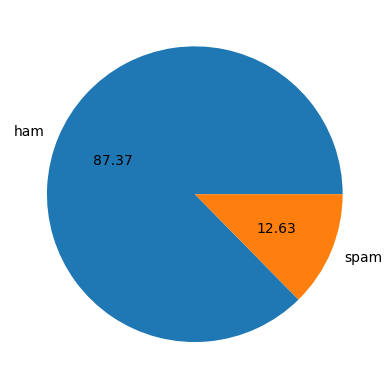

In [16]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [17]:

# Data is not balanced


In [18]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Huzaifa
[nltk_data]     Naeem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [19]:
#number of characters
df['num_characters']=df['text'].apply(len)

In [20]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [21]:
#number of words
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [22]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [23]:
#number of sentences
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [24]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
#for ham messages
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
#for spam messages
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

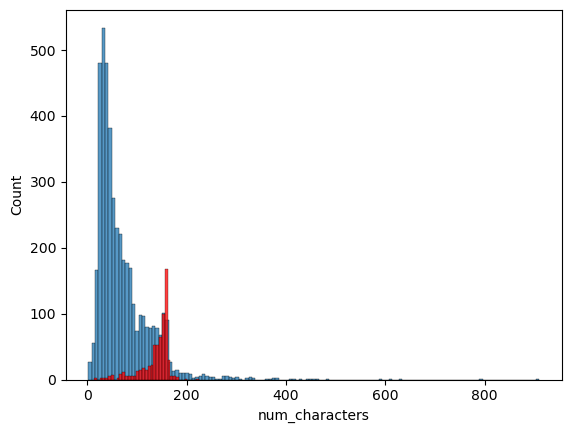

In [28]:
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

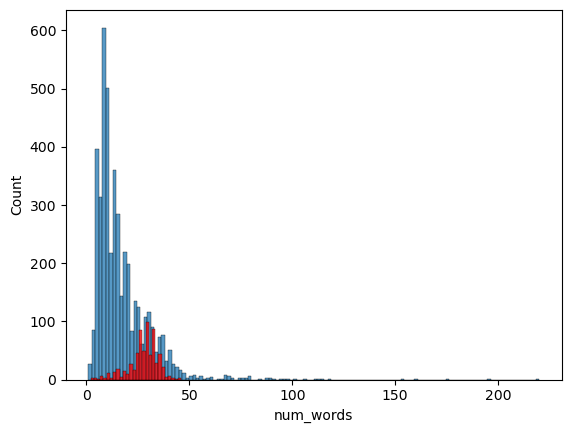

In [29]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

<Axes: xlabel='num_sentences', ylabel='Count'>

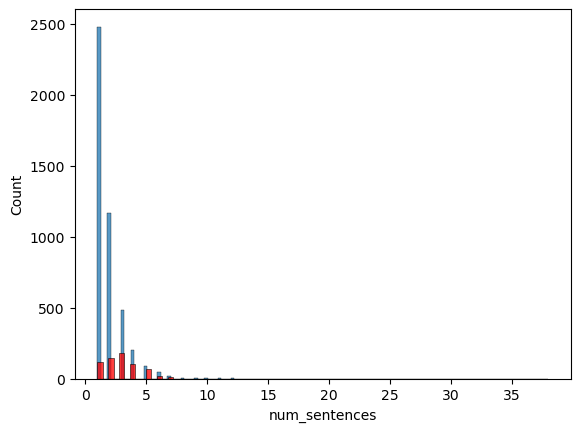

In [30]:
sns.histplot(df[df['target']==0]['num_sentences'])
sns.histplot(df[df['target']==1]['num_sentences'],color='red')

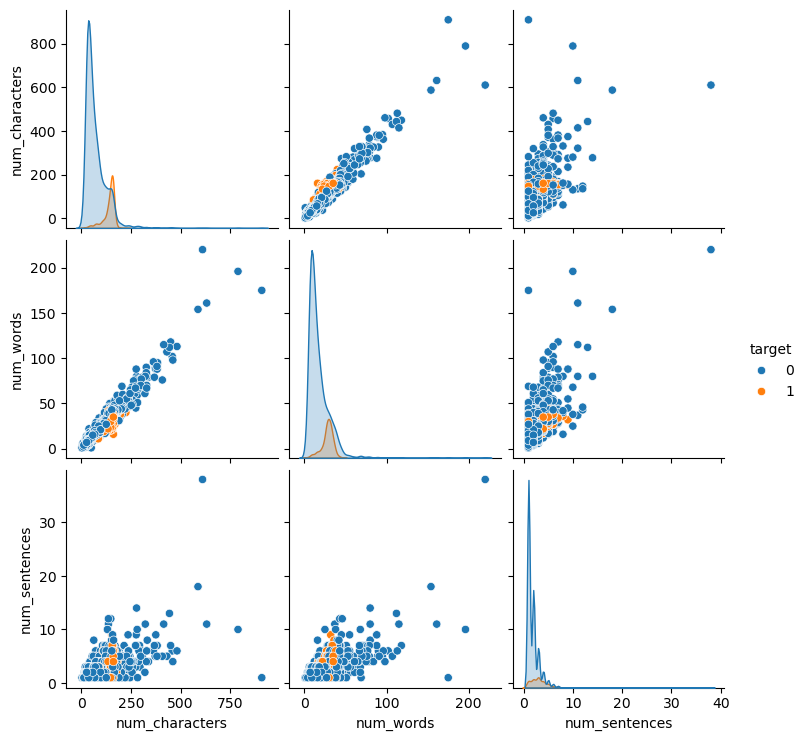

In [31]:

sns.pairplot(df,hue='target')

In [32]:
df.corr(numeric_only=True)

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

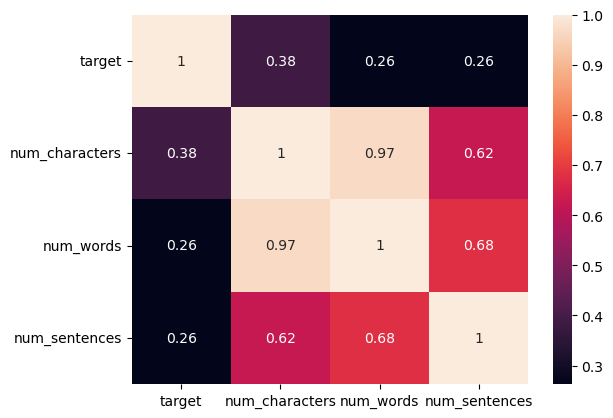

In [33]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# 3.Data preprocessing


In [34]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()


In [35]:
from nltk.corpus import stopwords
stopwords.words('english')


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [36]:

import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [37]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english')and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [38]:
df['transformed_text']=df['text'].apply(transform_text)

In [39]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [40]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

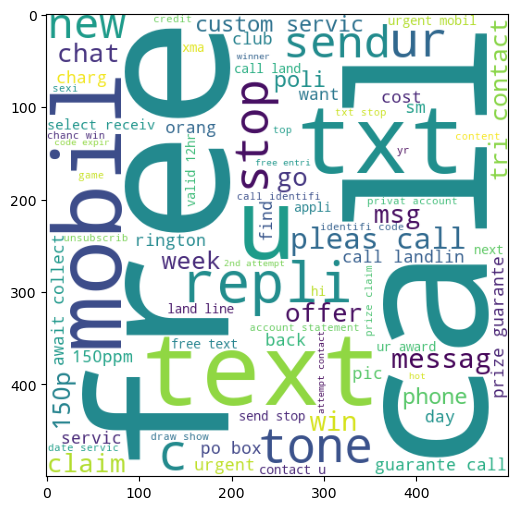

In [41]:
spam_words=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(spam_words)




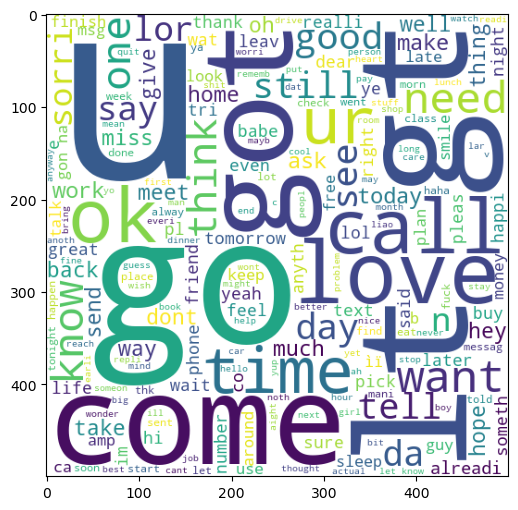

In [42]:
ham_words=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(15,6))
plt.imshow(ham_words)


In [43]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [44]:
len(spam_corpus)

9939

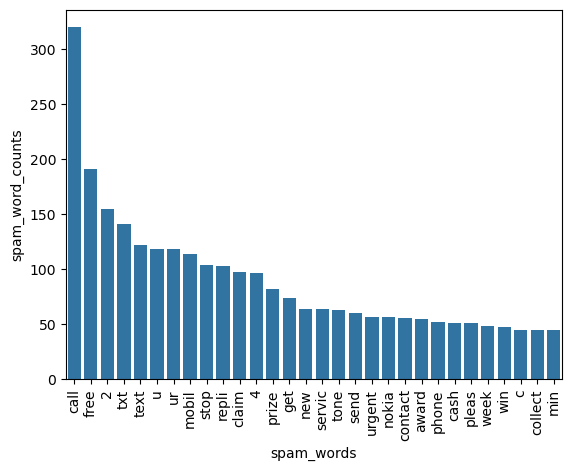

In [45]:
from collections import Counter
most_common_spam=pd.DataFrame(Counter(spam_corpus).most_common(30),columns=['spam_words','spam_word_counts'])

sns.barplot(x='spam_words',y= 'spam_word_counts',data=most_common_spam)
plt.xticks(rotation='vertical')
plt.show()

In [46]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [47]:
len(ham_corpus)

35404

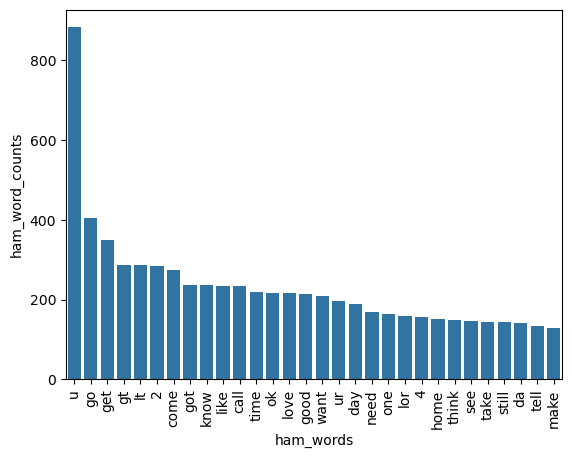

In [48]:
most_common_ham=pd.DataFrame(Counter(ham_corpus).most_common(30),columns=['ham_words','ham_word_counts'])

sns.barplot(x='ham_words',y= 'ham_word_counts',data=most_common_ham)
plt.xticks(rotation='vertical')
plt.show()

In [49]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# 4.Model Building

In [50]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
tfidf=TfidfVectorizer(max_features=3000)
cv=CountVectorizer()

In [51]:
# x=cv.fit_transform(df['transformed_text']).toarray()
x=tfidf.fit_transform(df['transformed_text']).toarray()


In [52]:
# appending the num_character col to x
# x = np.hstack((x,df['num_characters'].values.reshape(-1,1)))

In [53]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# x = scaler.fit_transform(x)

In [54]:
x.shape

(5169, 3000)

In [55]:
y=df['target'].values


In [56]:
y


array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=4)

In [59]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [60]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [61]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8617021276595744
[[781 125]
 [ 18 110]]
0.46808510638297873


In [62]:
mnb.fit(x_train,y_train)
y_pred2=mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.971953578336557
[[905   1]
 [ 28 100]]
0.9900990099009901


In [63]:
bnb.fit(x_train,y_train)
y_pred3=bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9825918762088974
[[903   3]
 [ 15 113]]
0.9741379310344828


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [65]:

lrc=LogisticRegression(solver='liblinear',penalty='l1')
svc =SVC(kernel ='sigmoid',gamma=1)
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
knc=KNeighborsClassifier()
rfc= RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt= GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb= XGBClassifier(n_estimators=50,random_state=2)

In [66]:
clfs={
    'SVC':svc,
    'KN':knc,
    'NB':mnb,
    'DT':dtc,
    'LR':lrc,
    'RF':rfc,
    'AdaBoost':abc,
    'BgC':bc,
    'ETC':etc,
    'GBDT':gbdt,
    'xgb':xgb
}


In [67]:
def train_classifier (clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)

    return accuracy,precision

In [68]:
accuracy_scores=[]
precision_scores=[]

for name,clf in clfs.items():
    current_accuracy,current_precision=train_classifier(clf,x_train,y_train,x_test,y_test)
    print ("For ",name)
    print("accuracy -",current_accuracy)
    print("precision -",current_precision)

    accuracy_scores.append(current_accuracy)
    
    precision_scores.append(current_precision)

For  SVC
accuracy - 0.9748549323017408
precision - 0.9553571428571429
For  KN
accuracy - 0.9148936170212766
precision - 1.0
For  NB
accuracy - 0.971953578336557
precision - 0.9900990099009901
For  DT
accuracy - 0.9400386847195358
precision - 0.8113207547169812
For  LR
accuracy - 0.9535783365570599
precision - 0.9444444444444444
For  RF
accuracy - 0.9700193423597679
precision - 0.9801980198019802
For  AdaBoost
accuracy - 0.9274661508704062
precision - 0.8192771084337349
For  BgC
accuracy - 0.9680851063829787
precision - 0.8925619834710744
For  ETC
accuracy - 0.9709864603481625
precision - 0.9711538461538461
For  GBDT
accuracy - 0.9535783365570599
precision - 0.9545454545454546
For  xgb
accuracy - 0.9671179883945842
precision - 0.9519230769230769


In [ ]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'precision':precision_scores}).sort_values('precision',ascending=False)

In [96]:
performance_df

,Algorithm,Accuracy,precision
1,KN,0.907157,1.000000
2,NB,0.957447,1.000000
5,RF,0.965184,0.989362
8,ETC,0.972921,0.971698
0,SVC,0.969052,0.961538
4,LR,0.950677,0.942529
10,xgb,0.964217,0.941748
7,BgC,0.969052,0.900000
6,AdaBoost,0.935203,0.896104
9,GBDT,0.946809,0.884211


In [71]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")


In [95]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.907157
1,NB,Accuracy,0.957447
2,RF,Accuracy,0.965184
3,ETC,Accuracy,0.972921
4,SVC,Accuracy,0.969052
5,LR,Accuracy,0.950677
6,xgb,Accuracy,0.964217
7,BgC,Accuracy,0.969052
8,AdaBoost,Accuracy,0.935203
9,GBDT,Accuracy,0.946809


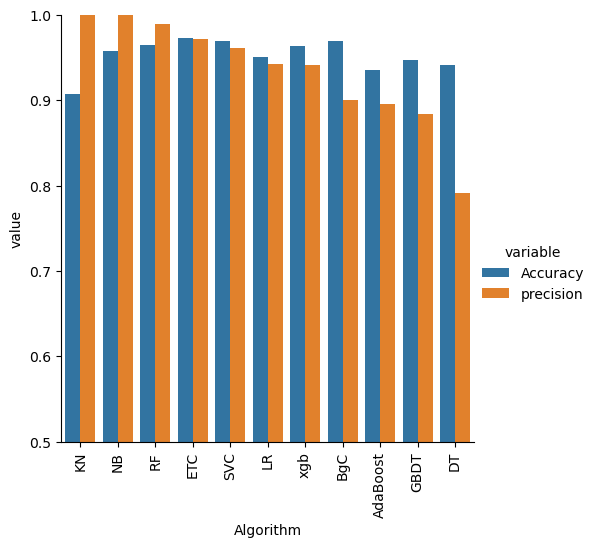

In [73]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')

plt.show()

# Model Improvement

In [74]:
 #apply the max_features parameter on tdidf 


In [97]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [124]:
temp2_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [99]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [100]:
new_df

,Algorithm,Accuracy,precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,KN,0.907157,1.000000,0.914894,1.000000
1,NB,0.957447,1.000000,0.971954,0.990099
2,RF,0.965184,0.989362,0.970019,0.980198
3,ETC,0.972921,0.971698,0.970986,0.971154
4,SVC,0.969052,0.961538,0.974855,0.955357
5,LR,0.950677,0.942529,0.953578,0.944444
6,xgb,0.964217,0.941748,0.967118,0.951923
7,BgC,0.969052,0.900000,0.968085,0.892562
8,AdaBoost,0.935203,0.896104,0.927466,0.819277
9,GBDT,0.946809,0.884211,0.953578,0.954545


In [125]:
new_df_scaled = new_df.merge(temp2_df,on='Algorithm')

In [126]:
new_df_scaled


,Algorithm,Accuracy,precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_scaling,Precision_scaling
0,KN,0.907157,1.000000,0.914894,1.000000,0.912959,0.975000
1,NB,0.957447,1.000000,0.971954,0.990099,0.975822,0.925620
2,RF,0.965184,0.989362,0.970019,0.980198,0.970019,0.980198
3,ETC,0.972921,0.971698,0.970986,0.971154,0.970986,0.971154
4,SVC,0.969052,0.961538,0.974855,0.955357,0.965184,0.918182
5,LR,0.950677,0.942529,0.953578,0.944444,0.956480,0.946237
6,xgb,0.964217,0.941748,0.967118,0.951923,0.967118,0.951923
7,BgC,0.969052,0.900000,0.968085,0.892562,0.968085,0.892562
8,AdaBoost,0.935203,0.896104,0.927466,0.819277,0.927466,0.819277
9,GBDT,0.946809,0.884211,0.953578,0.954545,0.953578,0.954545


In [150]:
temp3_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [151]:
new_df_scaled.merge(temp3_df,on='Algorithm')

,Algorithm,Accuracy,precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_scaling,Precision_scaling,Accuracy_num_chars,Precision_num_chars
0,KN,0.907157,1.000000,0.914894,1.000000,0.912959,0.975000,0.934236,0.777778
1,NB,0.957447,1.000000,0.971954,0.990099,0.975822,0.925620,0.936170,0.984375
2,RF,0.965184,0.989362,0.970019,0.980198,0.970019,0.980198,0.975822,0.990476
3,ETC,0.972921,0.971698,0.970986,0.971154,0.970986,0.971154,0.972921,0.971698
4,SVC,0.969052,0.961538,0.974855,0.955357,0.965184,0.918182,0.876209,0.000000
5,LR,0.950677,0.942529,0.953578,0.944444,0.956480,0.946237,0.955513,0.936170
6,xgb,0.964217,0.941748,0.967118,0.951923,0.967118,0.951923,0.973888,0.946903
7,BgC,0.969052,0.900000,0.968085,0.892562,0.968085,0.892562,0.962282,0.873950
8,AdaBoost,0.935203,0.896104,0.927466,0.819277,0.927466,0.819277,0.950677,0.913978
9,GBDT,0.946809,0.884211,0.953578,0.954545,0.953578,0.954545,0.948743,0.894737


In [100]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [101]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [102]:
voting.fit(x_train,y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [103]:
y_pred = voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9777562862669246
Precision 0.972972972972973


In [104]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [105]:
from sklearn.ensemble import StackingClassifier

In [106]:
clf = StackingClassifier(estimators=estimators , final_estimator=final_estimator)

In [107]:
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9835589941972921
Precision 0.944


In [108]:
#Mnb is final model
final_model = MultinomialNB()
final_model.fit(x_train, y_train)
y_pred = final_model.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.971953578336557
Precision 0.9900990099009901


In [109]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(final_model,open('model.pkl','wb'))